In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import opentnsim.fis as fis
import xarray as xr
%matplotlib inline

In [2]:
path = os.getcwd()

In [13]:
df = pd.read_csv(os.path.join(path,"rotterdam_data.csv"), delimiter=';', encoding='ISO-8859-1', on_bad_lines='skip')

In [15]:
df['TIME'] = df['WAARNEMINGDATUM'] + ' ' + df['WAARNEMINGTIJD (MET/CET)']
df['TIME'] = pd.to_datetime(df['TIME'], format = "%d-%m-%Y %H:%M:%S")
df = df[['TIME','MEETPUNT_IDENTIFICATIE','NUMERIEKEWAARDE','X','Y']]
df = df.rename(columns={'MEETPUNT_IDENTIFICATIE':'Location','NUMERIEKEWAARDE':'Water level'})
df = df.set_index('TIME')

In [16]:
df['Water level'] = df['Water level'].apply(lambda x: x if x < 200 else np.nan)
df['Water level'] = df['Water level'].interpolate()

In [17]:
botlek_data = df[df['Location'] == 'Geulhaven Radarpost 10']
HvH_data = df[df['Location'] == 'Hoek van Holland']
botlek_data.pop('Location')
HvH_data.pop('Location')

In [27]:
FG = fis.load_network(version="0.3")

In [42]:
import datetime
import simpy

# set simulation time
simulation_start = datetime.datetime(2024, 1, 1, 0, 0, 0)
simulation_stop = datetime.datetime(2024, 1, 8, 0, 0, 0)

# create time series aligned with simulation time
timestep = pd.Timedelta(minutes=5)
time_series = pd.date_range(simulation_start,simulation_stop,freq=timestep)

env = simpy.Environment(initial_time=simulation_start.timestamp())
env.simulation_start = simulation_start
env.simulation_stop = simulation_stop
env.epoch = simulation_start
env.graph = FG

In [56]:
def create_default_hydrodynamic_dataset(env,properties = ['Water level', 'Nautical depth']):
    default_values = {'Water level': 999., 'Nautical depth': -999.}
    stations = list(env.graph.nodes)
    times = pd.date_range(env.simulation_start,env.simulation_stop, freq=pd.Timedelta(minutes=5))
    hydrodynamic_data = xr.Dataset()
    for property_ in properties:
        default_value = default_values[property_]
        property_data = np.ones([len(stations),len(times)])*default_value
        property_da = xr.DataArray(property_data,coords={'STATION':stations, 'TIME':times})
        hydrodynamic_data[property_] = property_da
    return hydrodynamic_data

In [58]:
hydrodynamic_data = create_default_hydrodynamic_dataset(env)
hydrodynamic_data

<xarray.Dataset> Size: 504MB
Dimensions:         (STATION: 15584, TIME: 2017)
Coordinates:
  * STATION         (STATION) <U11 686kB '8861095' '8864054' ... '22638307'
  * TIME            (TIME) datetime64[ns] 16kB 2024-01-01 ... 2024-01-08
Data variables:
    Water level     (STATION, TIME) float64 251MB 999.0 999.0 ... 999.0 999.0
    Nautical depth  (STATION, TIME) float64 251MB -999.0 -999.0 ... -999.0

<Axes: xlabel='TIME'>

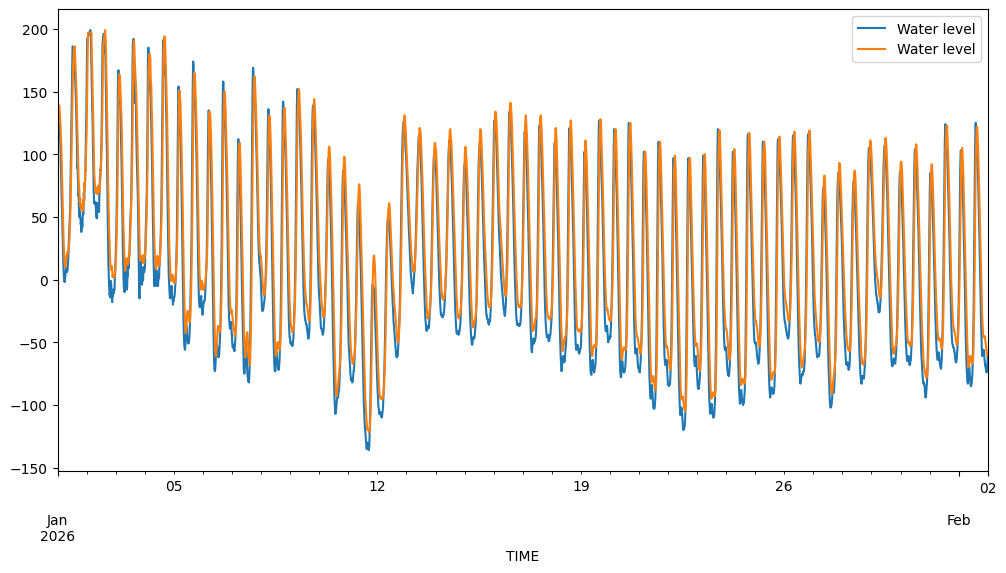

In [7]:
fig,ax = plt.subplots(figsize=[12,6])
HvH_data.plot(ax=ax, label='Hoek van Holland')
botlek_data.plot(ax=ax, label='Botlek')